# Pendahuluan

1. Tujuan:
* Mencari faktor apa saja yang menjadi penentu fleksibilitas keuangan perusahaan barang konsumsi (FMCG) di Indonesia

2. Hipotesis:
* H0 = Tidak ada pengaruh variabel X terhadap fleksibilas keuangan
* H1 = Terdapat pengaruh variabel X terhadap fleksibilas keuangan

3. Variabel X (independen) dan Y (dependen)
* Variabel X = Profitabilitas (ROA), Tangibility (TAS), Cash Holding (CRO), Struktur Modal (DTR), Retained Earnings (RNR), Ukuran Perusahaan (LTA)
* Variabel Y = Fleksibilitas Keuangan (FFR)

4. Referensi Utama:

> D. A. Nugraha, S. Muchtar, and A. Abyantara, "Faktor penentu fleksibilitas keuangan perusahaan barang konsumsi di Indonesia," *Jurnal Ekonomi Trisakti*, vol. 5, no. 2, pp. 1181-1188, 2025, doi: [10.25105/v5i2.23180](https://doi.org/10.25105/v5i2.23180).

5. Dataset
* Data didapatkan secara primer dengan menghubungi Author secara langsung

> **DISCLAIMER:** Data di referensi (penelitian) dengan data yang didapatkan ada sedikit perbedaan versi sehingga hasilnya akan berbeda

# Import dan Load Data

In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams

In [2]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [3]:
df_fmcg = pd.read_excel('https://drive.google.com/uc?id=1IHnAxLw5kz1QSveCgPCEbPE0FxlYT7jw')

In [4]:
df_fmcg.sample(5)

,Emiten,Tahun,FFR,ROA,TAS,CRO,DTR,RNR,LTA
54,NaN,2024,1,0.049114,0.219759,0.156189,0.067154,0.002486,15.105990
167,NaN,2022,1,0.074000,0.433558,0.146461,0.542613,0.000441,15.807127
0,ULTJ,2020,1,0.125620,0.177821,0.210149,0.453773,0.002045,15.985035
62,NaN,2022,0,0.031387,0.366141,0.049762,0.346722,0.029559,18.299220
74,NaN,2024,0,0.069660,0.407219,0.100323,0.754237,0.043455,16.280626


In [5]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df_fmcg[['ROA', 'TAS', 'CRO', 'DTR', 'RNR', 'LTA']]
Y = df_fmcg['FFR']

# Eksplorasi Data

## Statistik deskriptif

In [6]:
df_fmcg.shape

(170, 9)

In [7]:
# 2. Analisis Statistik Deskriptif
print("=== STATISTIK DESKRIPTIF ===")
df_fmcg[['FFR', 'ROA', 'TAS', 'CRO', 'DTR', 'RNR', 'LTA']].describe()

=== STATISTIK DESKRIPTIF ===


,FFR,ROA,TAS,CRO,DTR,RNR,LTA
count,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000
mean,0.382353,0.076005,0.353491,0.121511,0.463926,0.006684,15.993268
std,0.487398,0.087862,0.173978,0.119545,0.202611,0.012354,1.355194
min,0.000000,-0.116518,0.063919,0.001879,0.067154,-0.003457,13.606767
25%,0.000000,0.030074,0.237384,0.034100,0.317370,0.001027,14.904251
50%,0.000000,0.060233,0.319821,0.095046,0.463262,0.002522,16.038633
75%,1.000000,0.102406,0.447319,0.163337,0.584328,0.006573,17.048870
max,1.000000,0.599144,0.889917,0.621063,0.959044,0.073277,19.122358


In [8]:
df_fmcg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Emiten  34 non-null     object 
 1   Tahun   170 non-null    int64  
 2   FFR     170 non-null    int64  
 3   ROA     170 non-null    float64
 4   TAS     170 non-null    float64
 5   CRO     170 non-null    float64
 6   DTR     170 non-null    float64
 7   RNR     170 non-null    float64
 8   LTA     170 non-null    float64
dtypes: float64(6), int64(2), object(1)
memory usage: 12.1+ KB


## Visualisasi Persebaran

### Variabel Independen (X)

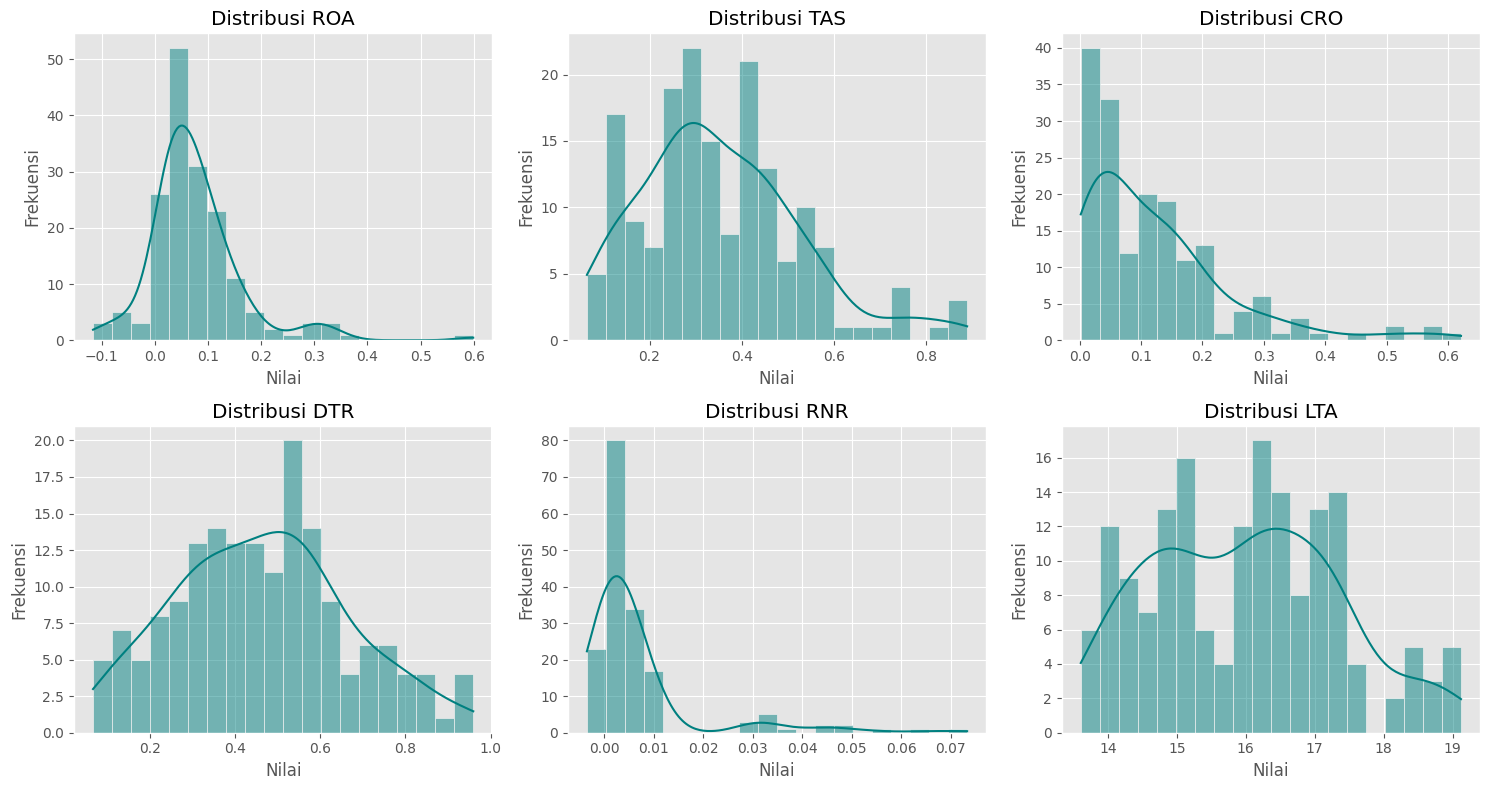

In [11]:
# Visualisasi Distribution Plot (Histogram dan KDE) untuk variabel independen (X)
fig, axes = plt.subplots(nrows=2, ncols=3)
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.histplot(df_fmcg[col], kde=True, ax=axes[i], color='teal', bins=20)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### Variabel Dependen (Y)

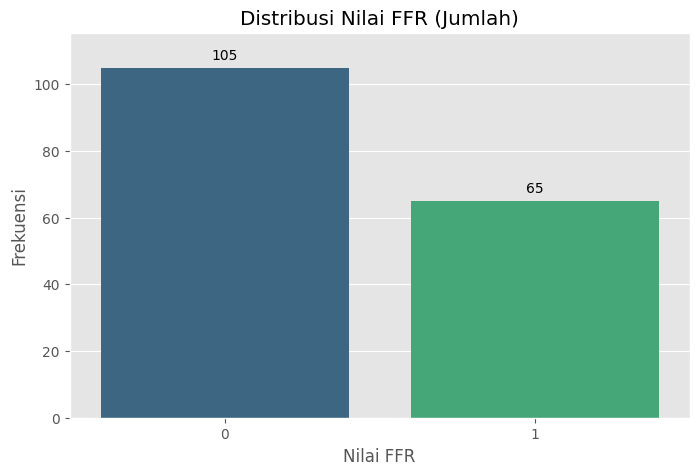

In [12]:
# Menghitung jumlah nilai
counts = df_fmcg['FFR'].value_counts()

# Visualisasi distribusi nilai FFR dalam jumlah (value)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index, legend=False)

# Menambahkan label teks jumlah di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('Distribusi Nilai FFR (Jumlah)')
plt.xlabel('Nilai FFR')
plt.ylabel('Frekuensi')
# Menyesuaikan limit y agar teks tidak terpotong
plt.ylim(0, counts.max() * 1.1)
plt.show()

# Uji Asumsi Klasik

Uji Asumsi Klasik yang dilakukan adalah Uji Multikolinearitas. Uji Normalitas dan Heteroskedastisitas tidak dilakukan karena regresi logistik tidak memerlukannya.

## Matriks Korelasi

Menggunakan matriks korelasi untuk melihat korelasi antara masing-masing variabel X. Didapatkan bahwa masing-masing variabel tidak berkorelasi kuat dengan nilai korelasi terendah adalah `-0.43` dan `0.29`. Angka treshold yang digunakan untuk Uji Moltikolinearitas tidak lolos adalah jika terdapat nilai korelasi lebih dari `0.8` atau kurang dari `-0.8`

<Axes: >

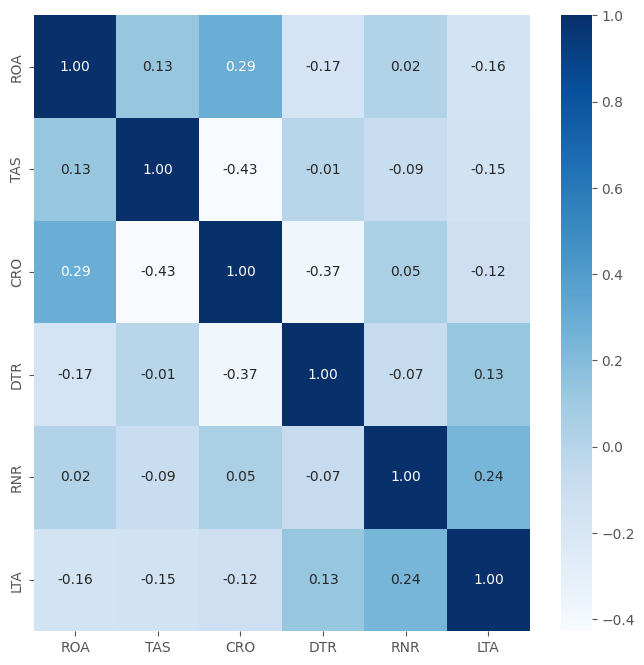

In [13]:
plt.figure(figsize=(8, 8))
sns.heatmap(X.corr(), cmap='Blues', annot=True, fmt='.2f')

## Variance Inflation Factor (VIF)

Uji Multikolinearitas menggunakan VIF. Jika nilai VIF >= 10, maka tidak lolos. Jika kurang maka lolos

In [20]:
print("=== UJI MULTIKOLINEARITAS (VIF) ===")
X_vif = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_vif.columns

vif_values = []
jumlah_kolom = len(X_vif.columns)

for i in range(jumlah_kolom):
    nilai_vif = variance_inflation_factor(X_vif.values, i)
    vif_values.append(nilai_vif)

vif_data["VIF"] = vif_values

# Menambahkan status kelulusan (Threshold VIF < 10)
vif_data['Status'] = vif_data['VIF'].apply(lambda x: 'Lolos' if x < 10 else 'Tidak Lolos')

# Menampilkan hasil tanpa konstanta
vif_data[vif_data['Variabel'] != 'const']

=== UJI MULTIKOLINEARITAS (VIF) ===


,Variabel,VIF,Status
1,ROA,1.202934,Lolos
2,TAS,1.438145,Lolos
3,CRO,1.713299,Lolos
4,DTR,1.221251,Lolos
5,RNR,1.082804,Lolos
6,LTA,1.146537,Lolos


# Uji Hipotesis - Regresi Logistik

In [15]:
print("=== HASIL REGRESI LOGISTIK ===")
X_log = sm.add_constant(X)
model = sm.Logit(Y, X_log)
result = model.fit()

print(result.summary())

=== HASIL REGRESI LOGISTIK ===
Optimization terminated successfully.
         Current function value: 0.191226
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                    FFR   No. Observations:                  170
Model:                          Logit   Df Residuals:                      163
Method:                           MLE   Df Model:                            6
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.7125
Time:                        09:34:56   Log-Likelihood:                -32.508
converged:                       True   LL-Null:                       -113.08
Covariance Type:            nonrobust   LLR p-value:                 3.375e-32
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.9613      5.209     -0.952      0.341     -15.171       5.24

Hal-hal yang bisa diobservasi:
1. Model Regresi Logistik secara umum dengan memasukan seluruh variabel X signifikan karena memiliki nilai LLR p-value yang kurang dari 0.05
2. Nilai Pseudo R-Square adalah 0.7125. Hal ini berarti seluruh variabel X dapat menjelaskan sebanyak 71.25% terhadap Y dan 28.75% dipengaruhi oleh faktor lain di luar model ini.
3. Untuk signifikansi antara masing-masing variabel dapat dilihat pada Kolom P>|z|. Dapat terlihat hanya CRO saja yang memiliki nilai kurang dari 0.05, yang berarti hanya CRO yang signifikan. Walaupun hanya 1 variabel saja, kita tetap berhasil menolak H0 dan menerima H1.


> **DISCLAIMER**: Di penelitian referensi, RNR juga masih termasuk signifikan. Karena memang adanya perbedaan data, kita anggap saja bahwa RNR juga masih layak untuk dipertahankan. Selain itu juga nilai P>|z| dari RNR adalah yang paling rendah dibandingkan variabel tidak signifikan yang lain

In [16]:
print("=== ODDS RATIO (Exp(B)) ===")

# Menghitung Odds Ratio berdasarkan kondisi
scaled_or = []
unscaled_or = []

for idx, val in result.params.items():
    # Logika untuk kolom 2 (Scaled 0.01) - Tidak berlaku untuk LTA
    if idx == 'LTA':
        scaled_or.append('-')
    else:
        scaled_or.append(np.exp(val * 0.01))

    # Logika untuk kolom 3 (Unscaled) - Hanya berlaku untuk LTA
    if idx == 'LTA':
        unscaled_or.append(np.exp(val))
    else:
        unscaled_or.append('-')

# Membuat DataFrame hasil
odds_ratio_df = pd.DataFrame({
    'Koefisien': result.params,
    'Odds Ratio (Scaled 0.01)': scaled_or,
    'Odds Ratio (Unscaled)': unscaled_or
})

odds_ratio_df

=== ODDS RATIO (Exp(B)) ===


,Koefisien,Odds Ratio (Scaled 0.01),Odds Ratio (Unscaled)
const,-4.961297,0.951598,-
ROA,-5.659227,0.944979,-
TAS,0.189983,1.001902,-
CRO,53.897071,1.714242,-
DTR,-1.273721,0.987344,-
RNR,24.908737,1.282854,-
LTA,-0.073473,-,0.929161


* Variabel ROA, TAS, CRO, DTR, dan RNR adalah nilai dalam bentuk persen, rasio (perbandingan), dsb. yang memiliki rentang nilai kecil. Sedangkan LTA memiliki rentang nilai yang lebih besar. Sehingga, nilai yang kecil dilakukan skala dikali 0.01, sedangkan LTA tetap. Jadi ini untuk mencegah nilai Odd Ratio yang terlalu tinggi ataupun terlalu rendah.

* Jadi untuk membaca tabel ini, kita berfokus saja ke CRO dan RNR. Pada nilai Koefisien, CRO dan RNR bernilai positif, yang berarti CRO dan RNR berpengaruh positif (searah) terhadap FFR atau Fleksibilitas. Jadi semakin tinggi CRO (cadangan kas dan likuiditas tinggi) ataupun RNR (laba ditahan yang tinggi mengurangi ketergantungan), maka semakin bisa menjaga fleksibilitas keuangan.

* Untuk Odd Ratio, setiap kenaikan 1% (0.01) pada CRO, maka FFR akan meningkat 1.71 kali lipat dan setiap kenaikan 1% (0.01) pada RNR, maka FFR akan meningkat 1.28 kali lipat